In [1]:
# =============================================================================
# CHUNK 1 — IMPORTS + GLOBAL CONFIG + LOAD DATA
# =============================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Randomizer = 485
np.random.seed(Randomizer)

WineReview_A = pd.read_csv("data/WineReview_A_cleaned.csv")
WineReview_B = pd.read_csv("data/WineReview_B_cleaned.csv")

In [2]:
# =============================================================================
# CHUNK 2 — FIX SENTIMENT LABELS
# =============================================================================

def fix_sentiment(df):
    return (
        df.assign(
            sentiment=df["sentiment"]
            .astype(str)
            .str.strip()
            .replace({
                "1": "positive",
                "-1": "negative",
                "0": "neutral"
            })
        )
    )

WineReview_A = fix_sentiment(WineReview_A)
WineReview_B = fix_sentiment(WineReview_B)

In [3]:
# =============================================================================
# CHUNK 3 — TF-IDF PIPELINE (5000 FEATURES)
# =============================================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

def tfidf_pipeline(df, max_features=5000, text_col="clean_text", label_col="sentiment"):

    tfidf = TfidfVectorizer(
        max_features=max_features,
        stop_words="english",
        lowercase=True
    )

    X = tfidf.fit_transform(df[text_col].astype(str))
    y = df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    return {
        "tfidf": tfidf,
        "X": X,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

A = tfidf_pipeline(WineReview_A, max_features=5000)
B = tfidf_pipeline(WineReview_B, max_features=5000)

In [4]:
# =============================================================================
# CHUNK 4 — 5-FOLD SVM CROSS-VALIDATION
# =============================================================================

from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate

def run_svm_cv(X_train, y_train, folds=5):

    svm = LinearSVC()
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    scores = cross_validate(
        svm,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        return_train_score=False
    )

    print("\nCV Accuracy Mean:", scores["test_accuracy"].mean())
    print("CV Precision Mean:", scores["test_precision_macro"].mean())
    print("CV Recall Mean:", scores["test_recall_macro"].mean())
    print("CV F1 Mean:", scores["test_f1_macro"].mean())

    return scores

cv_A = run_svm_cv(A["X_train"], A["y_train"])
cv_B = run_svm_cv(B["X_train"], B["y_train"])


CV Accuracy Mean: 0.7563696727271351
CV Precision Mean: 0.7481796267524117
CV Recall Mean: 0.6621406943332344
CV F1 Mean: 0.6902518956872197

CV Accuracy Mean: 0.7547510870665615
CV Precision Mean: 0.7436279064273077
CV Recall Mean: 0.6568557695125448
CV F1 Mean: 0.6846635725636977



Test Accuracy: 0.7632
Test Precision: 0.7525
Test Recall: 0.6707
Test F1: 0.6981

Classification Report:

              precision    recall  f1-score   support

    negative       0.72      0.42      0.53      2302
     neutral       0.75      0.82      0.78     12721
    positive       0.78      0.77      0.78      9292

    accuracy                           0.76     24315
   macro avg       0.75      0.67      0.70     24315
weighted avg       0.76      0.76      0.76     24315



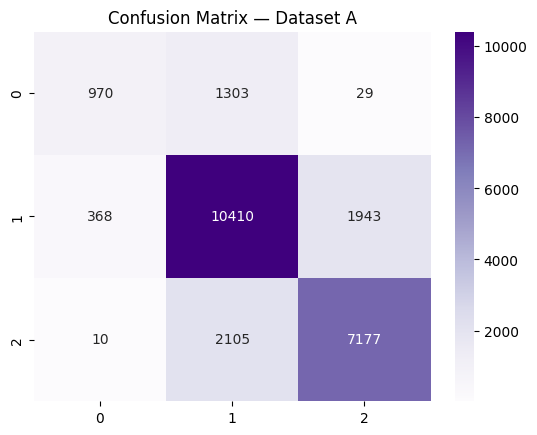

In [5]:
# =============================================================================
# CHUNK 5 — FINAL MODEL EVALUATION
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def final_svm_evaluation(X_train, y_train, X_test, y_test, title="Dataset"):

    svm_model = LinearSVC()
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    print("\nTest Accuracy:",  round(accuracy_score(y_test, y_pred), 4))
    print("Test Precision:", round(precision_score(y_test, y_pred, average='macro'), 4))
    print("Test Recall:",    round(recall_score(y_test, y_pred, average='macro'), 4))
    print("Test F1:",        round(f1_score(y_test, y_pred, average='macro'), 4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.title(f"Confusion Matrix — {title}")
    plt.show()

    return svm_model

model_A = final_svm_evaluation(
    A["X_train"], A["y_train"],
    A["X_test"], A["y_test"],
    title="Dataset A"
)

In [6]:
# =============================================================================
# CHUNK 6 — SAVE SVM MODEL + TF-IDF VECTORIZER
# =============================================================================

import pickle

with open("models/svm_sentiment.pkl", "wb") as f:
    pickle.dump(model_A, f)

with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(A["tfidf"], f)

print("SVM model + TF-IDF vectorizer saved to /models.")

SVM model + TF-IDF vectorizer saved to /models.


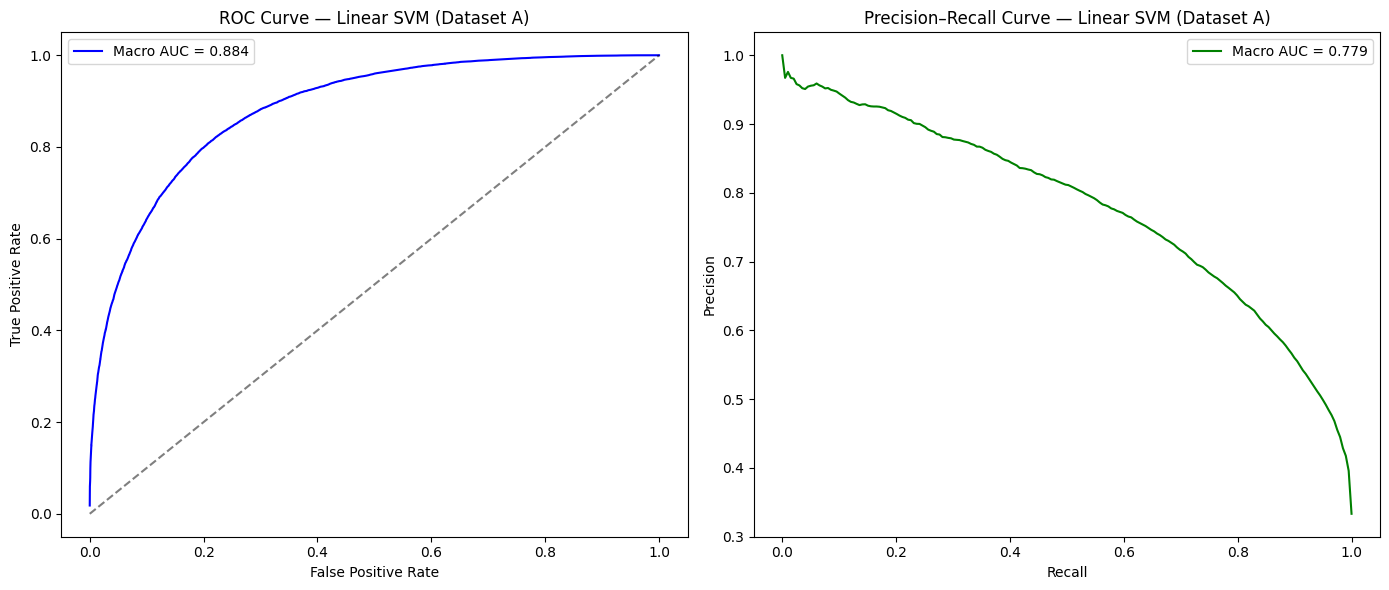

In [7]:
###############################################################################
#  MACRO-AVERAGED ROC + PRECISION–RECALL CURVES (SIDE-BY-SIDE) — DATASET A
###############################################################################

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# Use Dataset A test data explicitly
X_test_A = A["X_test"]
y_test_A = A["y_test"]

# Binarize labels
classes = np.unique(y_test_A)
y_bin = label_binarize(y_test_A, classes=classes)

# LinearSVC → use decision_function
scores = model_A.decision_function(X_test_A)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------------------------
# MACRO-AVERAGED ROC CURVE
# ---------------------------------------------------------------------------
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

axes[0].plot(all_fpr, mean_tpr, label=f"Macro AUC = {macro_auc:.3f}", color="blue")
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_title("ROC Curve — Linear SVM (Dataset A)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# ---------------------------------------------------------------------------
# MACRO-AVERAGED PRECISION–RECALL CURVE
# ---------------------------------------------------------------------------
pr_auc = []
mean_precision = None
mean_recall = np.linspace(0, 1, 200)

for i in range(len(classes)):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], scores[:, i])
    pr_auc.append(auc(recall, precision))

    # Interpolate precision for macro-average
    precision_interp = np.interp(mean_recall, recall[::-1], precision[::-1])

    if mean_precision is None:
        mean_precision = precision_interp
    else:
        mean_precision += precision_interp

mean_precision /= len(classes)
macro_pr_auc = np.mean(pr_auc)

axes[1].plot(mean_recall, mean_precision, color="green",
             label=f"Macro AUC = {macro_pr_auc:.3f}")

axes[1].set_title("Precision–Recall Curve — Linear SVM (Dataset A)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
###############################################################################
#  TOP TF-IDF FEATURES PER CLASS — DATASET A
###############################################################################

feature_names = A["tfidf"].get_feature_names_out()
class_labels = model_A.classes_

for i, cls in enumerate(class_labels):
    top10 = np.argsort(model_A.coef_[i])[-10:]
    print(f"\nTop features for {cls}:")
    print([feature_names[j] for j in top10])


Top features for negative:
['harsh', 'underdeveloped', 'mushy', 'terribly', 'marred', 'strange', 'fails', 'watery', 'weird', 'virginia']

Top features for neutral:
['quibble', 'muller', 'cast', 'grechetto', 'insolia', 'function', 'boy', 'soon', 'leyda', 'ripasso']

Top features for positive:
['terrific', 'superb', 'exquisite', 'impeccable', 'dazzling', 'impressive', 'stunning', 'gorgeous', 'beautiful', 'sample']


/tmp/ipykernel_185977/2658584965.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_185977/2658584965.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_185977/2658584965.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


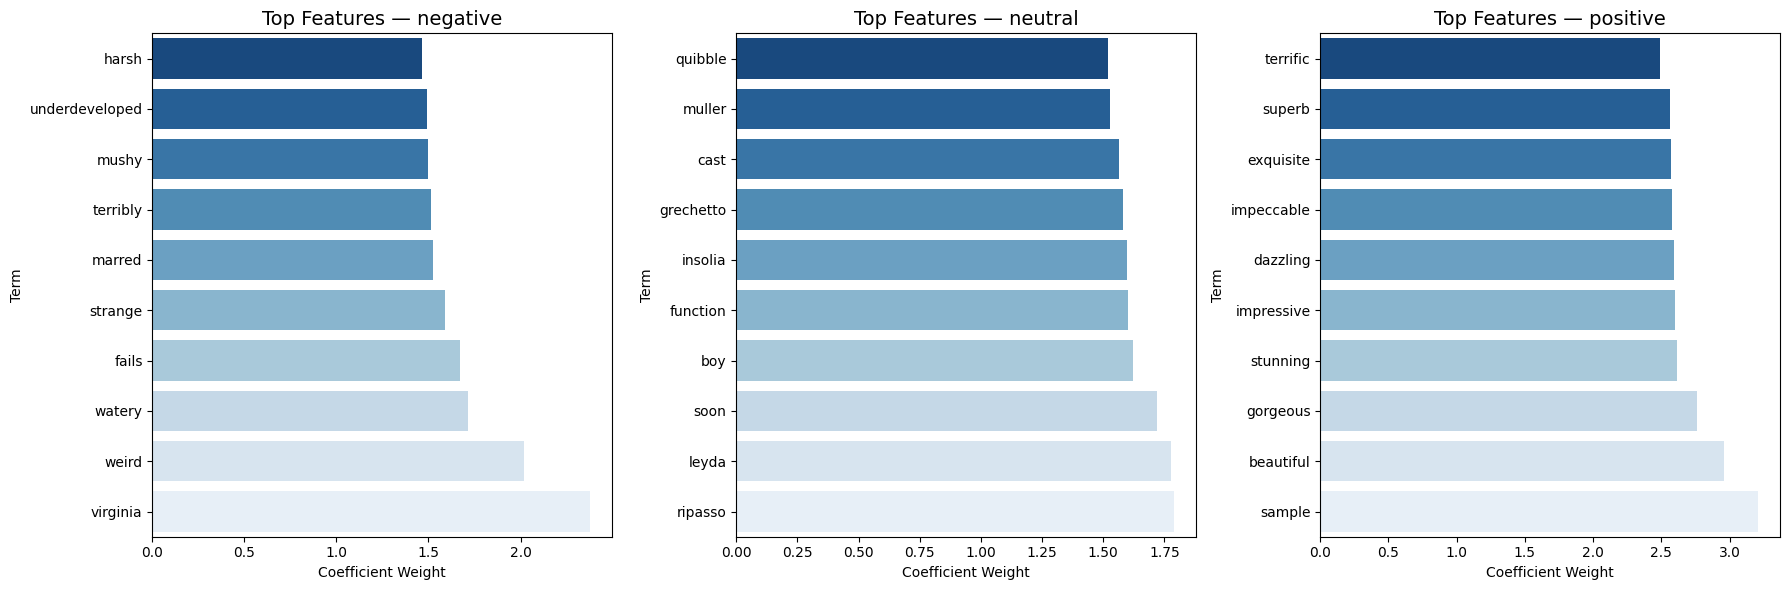

In [9]:
###############################################################################
#  TOP 10 FEATURES PER CLASS — 1×3 GRID (DATASET A)
###############################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature names and class labels
feature_names = A["tfidf"].get_feature_names_out()
class_labels = model_A.classes_

# Coefficient matrix: shape = (n_classes, n_features)
coefs = model_A.coef_

def get_top_features_for_class(class_index, top_n=10):
    """Return top N features for a given class index."""
    class_coefs = coefs[class_index]
    top_indices = np.argsort(class_coefs)[-top_n:]
    top_terms = feature_names[top_indices]
    top_weights = class_coefs[top_indices]

    return pd.DataFrame({
        "term": top_terms,
        "weight": top_weights
    }).sort_values("weight", ascending=True)

# Build plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cls in enumerate(class_labels):
    df_top = get_top_features_for_class(i, top_n=10)

    sns.barplot(
        data=df_top,
        x="weight",
        y="term",
        ax=axes[i],
        palette="Blues_r"
    )

    axes[i].set_title(f"Top Features — {cls}", fontsize=14)
    axes[i].set_xlabel("Coefficient Weight")
    axes[i].set_ylabel("Term")

plt.tight_layout()
plt.show()

In [10]:
###############################################################################
#  TABLE: WORD → CLASS → QUALITY TIER → DESIGNATION %  (DATASET A)
###############################################################################

import numpy as np
import pandas as pd

# -----------------------------
# Extract model coefficients
# -----------------------------
feature_names = A["tfidf"].get_feature_names_out()
class_labels = model_A.classes_
coefs = model_A.coef_

# Build coefficient table
coef_table = pd.DataFrame({
    "term": feature_names,
    "negative": coefs[0],
    "neutral":  coefs[1],
    "positive": coefs[2]
})

# -----------------------------
# Top 10 words per class
# -----------------------------
top_neg = (
    coef_table.nlargest(10, "negative")
    .assign(**{"class": "negative"})
)

top_neu = (
    coef_table.nlargest(10, "neutral")
    .assign(**{"class": "neutral"})
)

top_pos = (
    coef_table.nlargest(10, "positive")
    .assign(**{"class": "positive"})
)

top_words = pd.concat([top_neg, top_neu, top_pos], ignore_index=True)

# -----------------------------
# Add quality tier mapping
# -----------------------------
quality_map = {
    "negative": "Low-scoring wines (<85)",
    "neutral":  "Mid-tier wines (85–89)",
    "positive": "High-scoring wines (90+)"
}

top_words["quality_tier"] = top_words["class"].map(quality_map)

# -----------------------------
# Compute % of reviews with designation for each word
# -----------------------------
df_design = WineReview_A[["clean_text", "has_designation"]].copy()
df_design["clean_text"] = df_design["clean_text"].str.lower()

# explode words
df_design["words"] = df_design["clean_text"].str.split()
df_design = df_design.explode("words")

designation_map = (
    df_design.groupby("words")["has_designation"]
    .mean()
    .reset_index()
    .rename(columns={"words": "term", "has_designation": "pct_with_designation"})
)

# -----------------------------
# Merge into final table
# -----------------------------
final_table = top_words.merge(designation_map, on="term", how="left")

final_table = final_table[[
    "term", "class", "quality_tier", "pct_with_designation"
]]

final_table

,term,class,quality_tier,pct_with_designation
0,virginia,negative,Low-scoring wines (<85),1.0
1,weird,negative,Low-scoring wines (<85),1.0
2,watery,negative,Low-scoring wines (<85),1.0
3,fails,negative,Low-scoring wines (<85),1.0
4,strange,negative,Low-scoring wines (<85),1.0
5,marred,negative,Low-scoring wines (<85),1.0
6,terribly,negative,Low-scoring wines (<85),1.0
7,mushy,negative,Low-scoring wines (<85),1.0
8,underdeveloped,negative,Low-scoring wines (<85),1.0
9,harsh,negative,Low-scoring wines (<85),1.0
